# Investigating Gradient Descent for Linear Regression: The Effect of Learning Rate on Convergence

## 1. Introduction

Linear regression is a fundamental machine learning technique used to model the relationship between an input variable and a continuous output variable. In this project, we investigate how **gradient descent** can be used to find the parameters of a linear regression model.

Gradient descent is an optimization algorithm that repeatedly updates model parameters in order to minimize a loss function. One important factor affecting its behavior is the **learning rate**, which controls the size of each update.

### Objective

The main objective of this project is to investigate how different learning rates affect the convergence of gradient descent when training a linear regression model.

Specifically, we will:

* Implement linear regression using **NumPy**.
* Implement **gradient descent from scratch**.
* Use Mean Squared Error (MSE) as the loss function.
* Experiment with different learning rates.
* Visualize the convergence of the algorithm.
* Analyze how the learning rate affects the speed and stability of convergence.

### Research Question

**How does the learning rate affect the convergence of gradient descent when training a linear regression model?**


## 2. Mathematical Background and Methodology

### Linear Regression

We use a simple linear regression model to describe the relationship between an input variable \(x\) and an output variable \(y\).

The model is:

$$
\hat{y} = wx + b
$$

where:

* \(x\) is the input variable.
* \(\hat{y}\) is the predicted output.
* \(w\) is the weight (slope).
* \(b\) is the bias (intercept).

The goal is to find values of \(w\) and \(b\) that make the predictions as close as possible to the actual data.

### Loss Function

To measure how well our model fits the data, we use **Mean Squared Error (MSE)**:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

A smaller MSE means that the model's predictions are closer to the actual values.

### Gradient Descent

Gradient descent is an optimization algorithm used to minimize the MSE. It starts with initial values for \(w\) and \(b\), calculates the gradients of the loss function, and repeatedly updates the parameters.

The parameter updates are:

$$
w = w - \alpha \frac{\partial MSE}{\partial w}
$$

$$
b = b - \alpha \frac{\partial MSE}{\partial b}
$$

where \(\alpha\) is the **learning rate**.

The learning rate determines the size of each update. A very small learning rate may make convergence slow, while a very large learning rate may cause the algorithm to overshoot the minimum. We will investigate this behavior experimentally.

### Methodology

In this project, we will:

1. Create a simple dataset with a linear relationship.
2. Implement the linear regression model using NumPy.
3. Calculate the MSE.
4. Derive and implement the gradients.
5. Implement gradient descent from scratch.
6. Train the model using different learning rates.
7. Visualize and compare their convergence.
8. Analyze the results.
### Key Terms

* **Optimization algorithm:** A method used to find the best solution by minimizing or maximizing an objective. In our project, gradient descent minimizes the MSE.

* **Convergence:** The process of getting closer to a stable or optimal solution. In our project, convergence means the MSE becomes smaller and eventually stabilizes.

* **Learning rate (\(\alpha\)):** Controls the size of each update made by gradient descent.

* **Actual value (\(y\)):** The real value from our dataset.

* **Predicted value (\(\hat{y}\)):** The value predicted by our linear regression model.

* **MSE (Mean Squared Error):** Measures how far the predicted values are from the actual values. Lower MSE means better predictions.


## 3. Creating the Dataset

For this project, I create a simple dataset with one input variable \(x\) and one output variable \(y\). The data follows an approximately linear relationship, which makes it suitable for studying linear regression and gradient descent.

* (x): input variable
* \(y\): actual output value


In [28]:
import numpy as np


In [29]:
# input values

x = np.array([1,2,3,4,5,6,7,8,9,10])

#  actual output values

y = np.array([3,5,7,9,11,13,15,17,19,21])

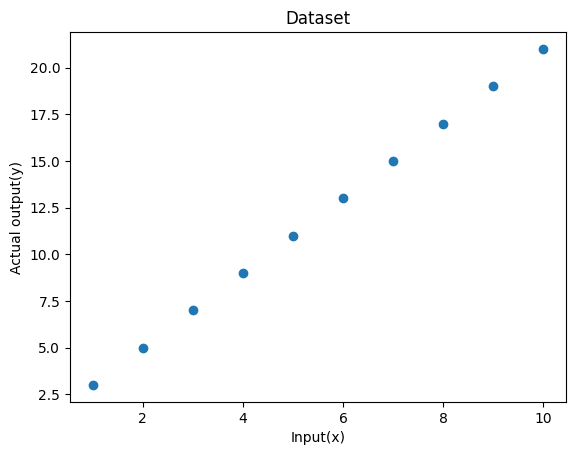

In [30]:
import matplotlib.pyplot as plt
plt.scatter(x,y)
plt.xlabel('Input(x)')
plt.ylabel('Actual output(y)')
plt.title('Dataset')
plt.show()

In [31]:
# Linear regression model
def predict(x,w,b):
  return w*x + b

In [32]:
# Initial values
w = 0
b = 0
y_predict = predict(x,w,b)
print('Predicted values', y_predict)

Predicted values [0 0 0 0 0 0 0 0 0 0]


In [33]:
def mse(y,y_predict):
  return np.mean((y-y_predict)**2)
loss = mse(y,y_predict)
print('Initial MSE:',loss)

Initial MSE: 177.0


In [34]:
# Implement gradient descent
def gradient_descent(x,y,w,b,learning_rate,iterations):
  n = len(y)
  loss_history = []
  for i in range(iterations):
    y_predict = w*x + b
    # calculate gradients
    dw = -(2/n) * np.sum(x*(y-y_predict))
    db = -(2/n) * np.sum(y-y_predict)
    # update parameters
    w = w - learning_rate * dw
    b = b - learning_rate * db
    # calculate loss
    loss = mse(y,y_predict)
    loss_history.append(loss)
  return w,b,loss_history

w_final,b_final,loss_history = gradient_descent(x,y,w=0,b=0,learning_rate=0.01,iterations=1000)
print('Final w:',w_final)
print('Final b:',b_final)
print('Final MSE:',loss_history[-1])

Final w: 2.0014915874253716
Final b: 0.9896158332966838
Final MSE: 2.3304498516671278e-05


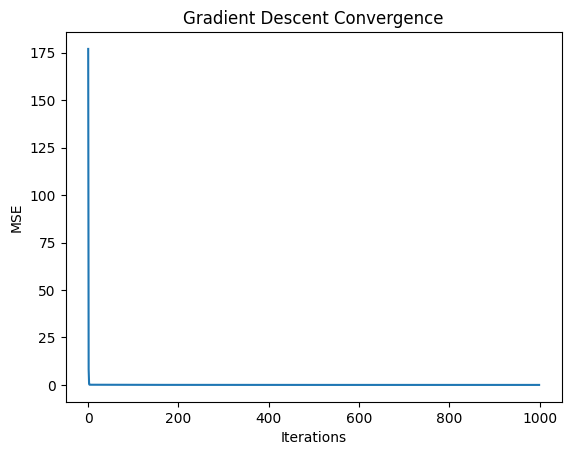

In [35]:
# now see actuall convergence
plt.plot(loss_history)
plt.xlabel('Iterations')
plt.ylabel('MSE')
plt.title('Gradient Descent Convergence')
plt.show()

In [36]:

# 0.001 → gradual decrease in MSE
# 0.01 → much faster decrease toward zero
# 0.1 → MSE becomes extremely large / unstable
learning_rates = [0.001,0.01,0.1]
results = {}
for lr in learning_rates:
  w_final,b_final,loss_history = gradient_descent(x,y,w=0,b=0,learning_rate=lr,iterations=1000)
  results[lr] = {'w':w_final,'b':b_final,'loss_history':loss_history}
  print(f'Learning rate: {lr}')
  print(f'Final w: {w_final}')
  print(f'Final b: {b_final}')
  print(f'Final MSE: {loss_history[-1]}')


Learning rate: 0.001
Final w: 2.0659028067142335
Final b: 0.5411963660349371
Final MSE: 0.045150196697311
Learning rate: 0.01
Final w: 2.0014915874253716
Final b: 0.9896158332966838
Final MSE: 2.3304498516671278e-05
Learning rate: 0.1
Final w: nan
Final b: nan
Final MSE: nan


/tmp/ipykernel_909/1995321811.py:2: RuntimeWarning: overflow encountered in square
  return np.mean((y-y_predict)**2)
/tmp/ipykernel_909/3843116392.py:8: RuntimeWarning: overflow encountered in multiply
  dw = -(2/n) * np.sum(x*(y-y_predict))
/tmp/ipykernel_909/3843116392.py:11: RuntimeWarning: invalid value encountered in scalar subtract
  w = w - learning_rate * dw


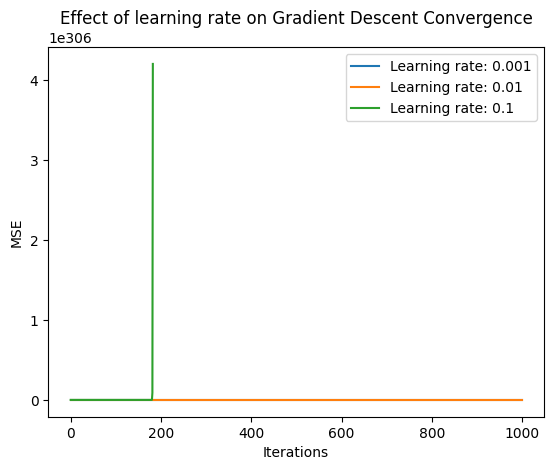

In [37]:
for lr in learning_rates:
  plt.plot(results[lr]['loss_history'],label=f'Learning rate: {lr}')
plt.xlabel('Iterations')
plt.ylabel('MSE')
plt.title('Effect of learning rate on Gradient Descent Convergence')
plt.legend()
plt.show()

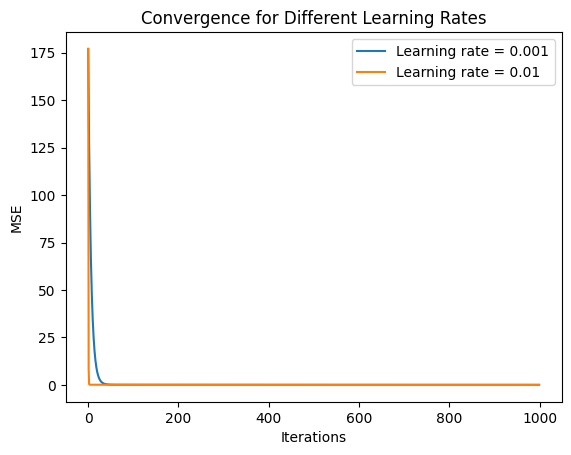

In [38]:
plt.plot(results[0.001]["loss_history"], label="Learning rate = 0.001")
plt.plot(results[0.01]["loss_history"], label="Learning rate = 0.01")

plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.title("Convergence for Different Learning Rates")
plt.legend()
plt.show()

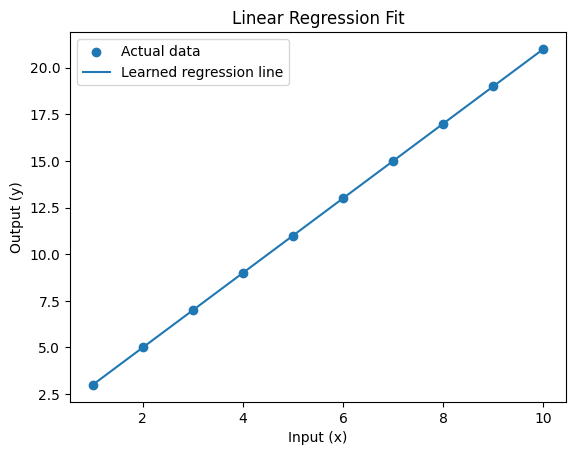

In [39]:
# final model graph
# Predictions using our best learning rate
w_best = results[0.01]["w"]
b_best = results[0.01]["b"]

y_pred_best = predict(x, w_best, b_best)

# Plot actual data
plt.scatter(x, y, label="Actual data")

# Plot learned regression line
plt.plot(x, y_pred_best, label="Learned regression line")

plt.xlabel("Input (x)")
plt.ylabel("Output (y)")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()

## 4. Results and Analysis

We tested three different learning rates: 0.001, 0.01, and 0.1.

The learning rate of **0.001** reduced the MSE gradually, but after 1000 iterations the model had not fully converged.

The learning rate of **0.01** produced much faster and more stable convergence. It reached a very small MSE and the learned parameters were close to the expected values \(w=2\) and \(b=1\).

The learning rate of **0.1** was too large for this dataset. The updates became unstable, causing the values to grow excessively and eventually resulting in `nan` values.

Overall, the experiment shows that the learning rate has a significant effect on both the **speed and stability of gradient descent**. For this dataset and the chosen number of iterations, 0.01 performed best among the tested learning rates.


## 5. Conclusion

In this project, we implemented linear regression and gradient descent from scratch using NumPy. We investigated how different learning rates affect the convergence of the algorithm.

The results showed that a very small learning rate can make convergence slow, while a very large learning rate can make the algorithm unstable. A suitable learning rate allowed the model to converge quickly and accurately.

This experiment demonstrates the importance of choosing an appropriate learning rate when using gradient descent for optimization.
